# Deskriptive Analyse — Qualitäts-Muster-Finder

**Basis:** `analysetabelle.csv` (1.824 Krankenhäuser, 18 Spalten)  
**Ziel:** 12 aussagekräftige Grafiken + je ein Befundsatz

Struktur:
1. Setup & Daten laden
2. Einzelne Merkmale (univariat)
3. Gruppenvergleiche: MIT vs. OHNE viele Probleme
4. Korrelationen & Zusammenhänge
5. Störfaktoren aufspüren
6. Befunde zusammenfassen

### 1 Setup
Bibliotheken laden (`pandas`, `numpy`, `matplotlib`, `seaborn`), einheitliches Farbschema festlegen (🟢 grün = wenige Probleme, 🔴 rot = viele Probleme), `analysetabelle.csv` einlesen und Koordinatenspalten von Komma- auf Punkt-Dezimalschreibweise umstellen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Einheitliches Design
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

FARBEN = {0: "#2ecc71", 1: "#e74c3c"}   # grün = wenig Probleme, rot = viele
LABELS  = {0: "Wenige Probleme", 1: "Viele Probleme"}

df = pd.read_csv("../Data/analysetabelle.csv", low_memory=False)

# Latitude/Longitude: Komma → Punkt
for col in ["SO.Latitude", "SO.Longitude"]:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False).pipe(pd.to_numeric, errors="coerce")

print(f"Datensatz: {df.shape}")
print(f"Ziel-Variable: {df['hat_viele_Probleme'].value_counts().to_dict()}")
df.head(3)

Datensatz: (1824, 18)
Ziel-Variable: {0: 925, 1: 899}


,SO.QBID,total_qi,auffaellig_n,auffaellig_quote,hat_viele_Probleme,SO.Name,SO.Betten,SO.Bundesland,SO.Uni,KH.Träger,KH.Träger.Art,SO.Latitude,SO.Longitude,SO.Standortnummer,fortbildungsquote,aerzte_pro_bett,pflege_pro_bett,ist_konzern
0,4876,19,18,0.947368,1,Park-Klinik GmbH,39,Schleswig-Holstein,0,Park-Klinik GmbH,privat,54.326732,10.125615,773063000,1.0,0.358974,2.415128,0
1,4878,2,2,1.000000,1,Johanniter Tagesklinik Schwarzenbek,0,Schleswig-Holstein,0,Johanniter-Krankenhaus Geesthacht GmbH,freigemeinnützig,53.505720,10.478568,772344000,1.0,NaN,NaN,0
2,4879,24,17,0.708333,0,Sankt Elisabeth Krankenhaus Kiel,43,Schleswig-Holstein,0,Lubinus-Kliniken GmbH,freigemeinnützig,54.316855,10.127381,771993000,1.0,0.800000,0.828372,0


---
## 2 Einzelne Merkmale untersuchen (univariat)

**Was heißt "univariat"?** Der Begriff kommt aus dem Lateinischen (*unus* = eins, *varia* = veränderlich) und bezeichnet die Betrachtung **eines einzelnen Merkmals für sich allein** — ohne es mit einem anderen Merkmal in Beziehung zu setzen. Das Gegenstück ist die **bivariate** Analyse (zwei Merkmale gleichzeitig, z. B. ein Streudiagramm) bzw. die **multivariate** Analyse (mehrere Merkmale gleichzeitig, wie später beim Decision Tree in `03_Decision_Tree.ipynb`).

**Warum univariat zuerst?** Bevor man prüft, ob zwei Merkmale zusammenhängen (Kapitel 4), muss man jedes Merkmal erst für sich verstehen: Wie ist es verteilt? Gibt es Ausreißer oder fehlende Werte? Unterscheiden sich die beiden Gruppen (wenige vs. viele Probleme) überhaupt sichtbar? Ohne diesen Schritt würde man möglicherweise Tests auf Merkmale anwenden, die offensichtlich nichts hergeben, oder Ausreißer übersehen, die das Ergebnis später verzerren.

In diesem Abschnitt entstehen die Grafiken 1–7 sowie 11–12 — je eine Grafik pro Merkmal, verglichen zwischen den beiden Gruppen `hat_viele_Probleme = 0` (wenige Probleme) und `= 1` (viele Probleme).

### 📊 Grafik 1 — Verteilung der auffällig-Quote
Histogramm der `auffaellig_quote` über alle 1.824 Häuser. Balken links vom Median blau, rechts orange. Medianline als gestrichelte graue Linie. Zeigt, wie die Ziel-Variable selbst verteilt ist — Grundlage für alle weiteren Gruppenvergleiche.

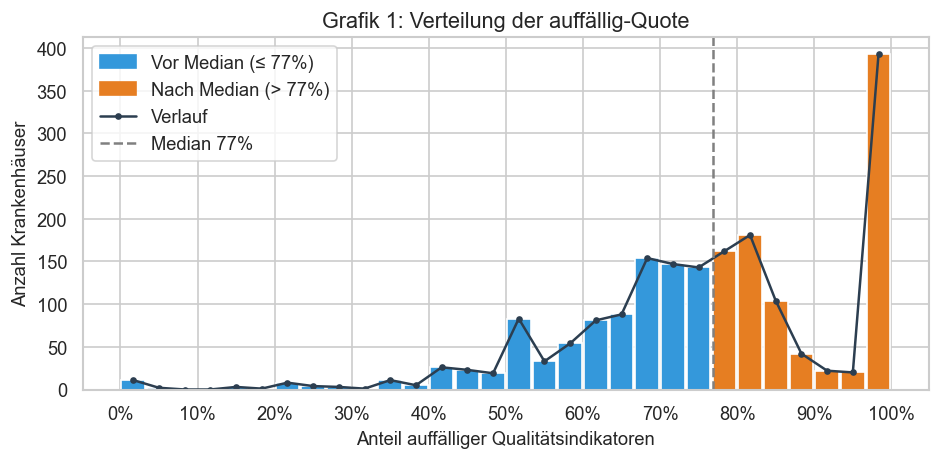


📌 Befund: Die auffällig-Quote ist linkssteil verteilt — die meisten Häuser liegen zwischen 60–90%. Der Median liegt bei 77%.


In [2]:
# ── Grafik 1: Verteilung der auffällig-Quote ─────────────────────
median = df["auffaellig_quote"].median()

fig, ax = plt.subplots(figsize=(8, 4))

# Bins einmal berechnen, dann beide Gruppen mit gleichen Bins zeichnen
counts_all, bin_edges = np.histogram(df["auffaellig_quote"].dropna(), bins=30)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Blau = vor Median, Orange = nach Median
colors = ["#3498db" if c <= median else "#e67e22" for c in bin_centers]
ax.bar(bin_centers, counts_all, width=bin_width * 0.92, color=colors, edgecolor="white")

ax.plot(bin_centers, counts_all, color="#2c3e50", linewidth=1.5, marker="o", markersize=3,
        label="Verlauf der Balkenhöhen")
ax.axvline(median, color="gray", linestyle="--",
           label=f"Median = {median:.0%}")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#3498db", label=f"Vor Median (≤ {median:.0%})"),
    Patch(color="#e67e22", label=f"Nach Median (> {median:.0%})"),
    plt.Line2D([0], [0], color="#2c3e50", linewidth=1.5, marker="o", markersize=3, label="Verlauf"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label=f"Median {median:.0%}"),
])

ax.set_xlabel("Anteil auffälliger Qualitätsindikatoren")
ax.set_ylabel("Anzahl Krankenhäuser")
ax.set_title("Grafik 1: Verteilung der auffällig-Quote")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
plt.tight_layout()
plt.show()

print("\n📌 Befund: Die auffällig-Quote ist linkssteil verteilt — "
      "die meisten Häuser liegen zwischen 60–90%. "
      "Der Median liegt bei {:.0%}.".format(median))

### 📊 Grafik 2 — Bettenzahl
Links: Histogramm der Bettenzahl (gekappt bei 1.500, damit einzelne Großkliniken die Skala nicht verzerren). Rechts: Boxplot der Bettenzahl getrennt nach Gruppe (wenige/viele Probleme) — zeigt, ob Hausgröße mit Qualitätsproblemen zusammenhängt.

C:\Users\Admin\AppData\Local\Temp\ipykernel_11532\1031469145.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_groups, labels=["Wenige Probleme", "Viele Probleme"],


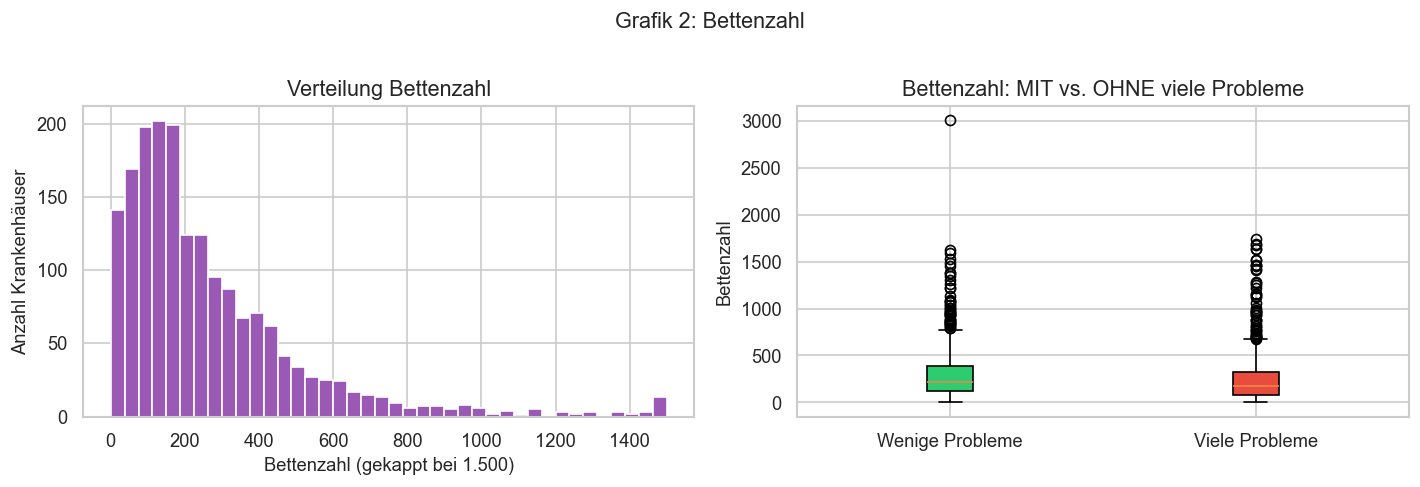


📌 Befund: Median Betten — Wenige Probleme: 214, Viele Probleme: 170. Kein klarer Größenunterschied.


In [3]:
# ── Grafik 2: Bettenzahl — Histogramm ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Histogramm
axes[0].hist(df["SO.Betten"].clip(upper=1500), bins=40, color="#9b59b6", edgecolor="white")
axes[0].set_xlabel("Bettenzahl (gekappt bei 1.500)")
axes[0].set_ylabel("Anzahl Krankenhäuser")
axes[0].set_title("Verteilung Bettenzahl")

# Boxplot nach Ziel-Variable
data_groups = [df[df["hat_viele_Probleme"]==0]["SO.Betten"],
               df[df["hat_viele_Probleme"]==1]["SO.Betten"]]
bp = axes[1].boxplot(data_groups, labels=["Wenige Probleme", "Viele Probleme"],
                     patch_artist=True,
                     boxprops=dict(facecolor="#ecf0f1"))
bp["boxes"][0].set_facecolor(FARBEN[0])
bp["boxes"][1].set_facecolor(FARBEN[1])
axes[1].set_ylabel("Bettenzahl")
axes[1].set_title("Bettenzahl: MIT vs. OHNE viele Probleme")

plt.suptitle("Grafik 2: Bettenzahl", fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

m0 = df[df["hat_viele_Probleme"]==0]["SO.Betten"].median()
m1 = df[df["hat_viele_Probleme"]==1]["SO.Betten"].median()
print(f"
📌 Befund: Median Betten — Wenige Probleme: {m0:.0f}, Viele Probleme: {m1:.0f}. "
      f"{'Häuser mit vielen Problemen sind im Median größer.' if m1>m0 else 'Kein klarer Größenunterschied.'}")

### 📊 Grafik 3 — Trägerschaft
Gruppiertes Balkendiagramm: Anteil „Wenige Probleme" vs. „Viele Probleme" je Trägerart (privat / freigemeinnützig / öffentlich). Zeigt, ob die Trägerschaft mit der Auffälligkeitsquote zusammenhängt.

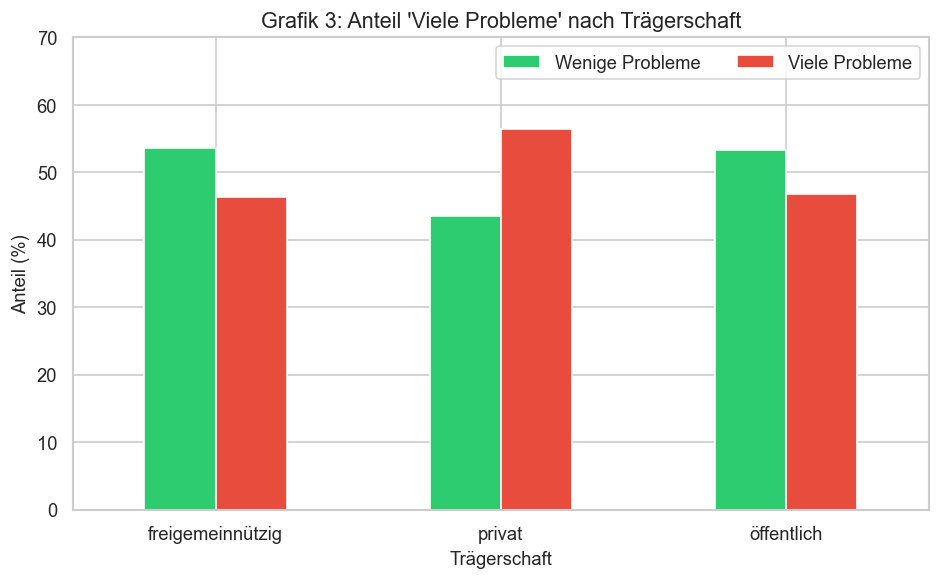

  privat              : 56.5% haben viele Probleme  (n=503)
  freigemeinnützig    : 46.4% haben viele Probleme  (n=608)
  öffentlich          : 46.7% haben viele Probleme  (n=685)

📌 Befund: Prüfen ob sich Trägerarten systematisch unterscheiden.


In [4]:
# ── Grafik 3: Trägerschaft ───────────────────────────────────────
traeger_counts = (
    df.groupby(["KH.Träger.Art", "hat_viele_Probleme"])
    .size().reset_index(name="n")
)
traeger_pct = traeger_counts.copy()
total = traeger_counts.groupby("KH.Träger.Art")["n"].transform("sum")
traeger_pct["pct"] = traeger_counts["n"] / total * 100

fig, ax = plt.subplots(figsize=(8, 5))
pivot = traeger_pct.pivot(index="KH.Träger.Art", columns="hat_viele_Probleme", values="pct")
pivot.columns = [LABELS[c] for c in pivot.columns]
pivot.plot(kind="bar", ax=ax, color=[FARBEN[0], FARBEN[1]], edgecolor="white")
ax.set_xlabel("Trägerschaft")
ax.set_ylabel("Anteil (%)")
ax.set_title("Grafik 3: Anteil 'Viele Probleme' nach Trägerschaft")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 70)   # Kopffreiheit, damit die Legende keine Balken überdeckt
ax.legend(title="", ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

for traeger in df["KH.Träger.Art"].dropna().unique():
    sub = df[df["KH.Träger.Art"]==traeger]
    pct = sub["hat_viele_Probleme"].mean()
    print(f"  {traeger:20s}: {pct:.1%} haben viele Probleme  (n={len(sub)})")
print("\n📌 Befund: Prüfen ob sich Trägerarten systematisch unterscheiden.")

### 📊 Grafik 4 — Uni-Kliniken vs. normale Häuser
Balkendiagramm: Anteil „Viele Probleme" für Uni-Kliniken vs. normale Häuser. Prüft die Hypothese, dass akademische Kliniken durch intensivere Forschung und Facharztdichte besser abschneiden.

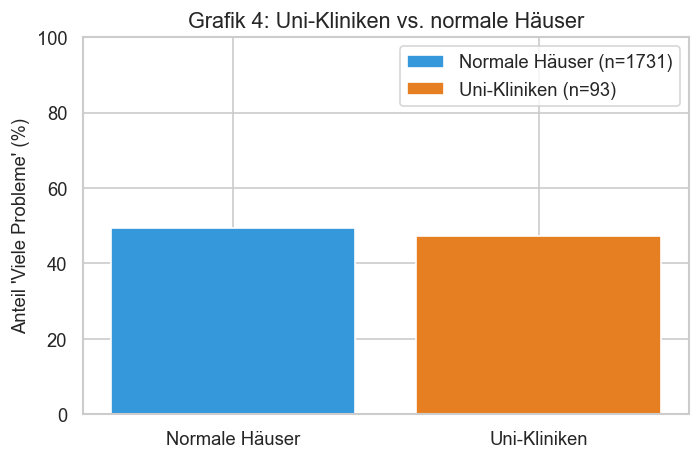

  Uni-Kliniken:    47.3% haben viele Probleme (n=93)
  Normale Häuser:  49.4% haben viele Probleme (n=1731)

📌 Befund: Vergleich Uni- vs. Nicht-Uni-Kliniken hinsichtlich Qualitätsproblemen.


In [5]:
# ── Grafik 4: Uni-Kliniken vs. normale Häuser ────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
uni_pct = (
    df.groupby("SO.Uni")["hat_viele_Probleme"].mean() * 100
).rename({0: "Normale Häuser", 1: "Uni-Kliniken"})
uni_n = df.groupby("SO.Uni").size().rename({0: "Normale Häuser", 1: "Uni-Kliniken"})
bars = ax.bar(uni_pct.index, uni_pct.values, color=["#3498db", "#e67e22"], edgecolor="white")
for bar, name in zip(bars, uni_pct.index):
    bar.set_label(f"{name} (n={uni_n[name]})")
ax.set_ylabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 4: Uni-Kliniken vs. normale Häuser")
ax.set_ylim(0, 100)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

n_uni   = df[df["SO.Uni"]==1]
n_norm  = df[df["SO.Uni"]==0]
print(f"  Uni-Kliniken:    {n_uni['hat_viele_Probleme'].mean():.1%} haben viele Probleme (n={len(n_uni)})")
print(f"  Normale Häuser:  {n_norm['hat_viele_Probleme'].mean():.1%} haben viele Probleme (n={len(n_norm)})")
print("\n📌 Befund: Vergleich Uni- vs. Nicht-Uni-Kliniken hinsichtlich Qualitätsproblemen.")

---
## 3️⃣ Gruppenvergleiche: Metrische Merkmale MIT vs. OHNE

### 📊 Grafiken 5+6 — Fortbildungsquote & Ärzte pro Bett
Zwei Boxplots nebeneinander: Fortbildungsquote und Ärzte pro Bett, jeweils getrennt nach Gruppe. Zeigt, ob mehr Personal oder höhere Fortbildungsbeteiligung mit weniger Qualitätsproblemen einhergeht. Ausreißer werden ausgeblendet (`showfliers=False`) für bessere Lesbarkeit.

C:\Users\Admin\AppData\Local\Temp\ipykernel_11532\3721214068.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Wenige Probleme", "Viele Probleme"],
C:\Users\Admin\AppData\Local\Temp\ipykernel_11532\3721214068.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Wenige Probleme", "Viele Probleme"],


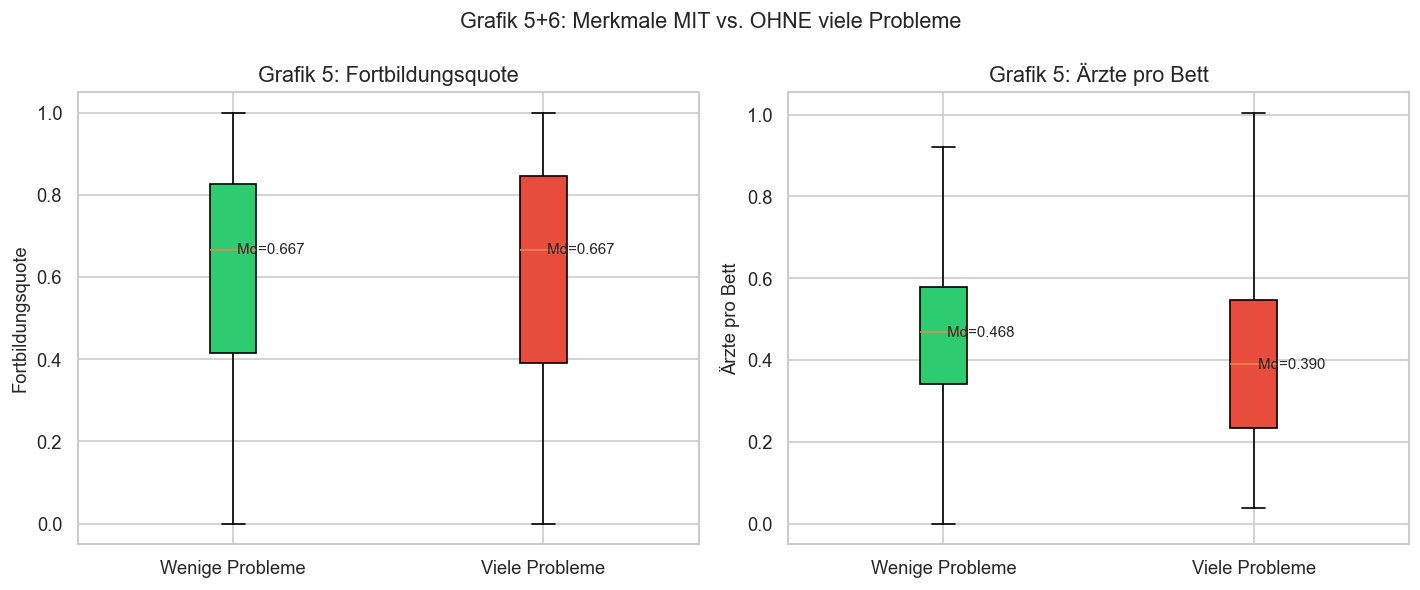

  Fortbildungsquote   : Wenige=0.667, Viele=0.667
  Ärzte/Bett          : Wenige=0.468, Viele=0.390

📌 Befund: Prüfen ob Fortbildungsquote oder Ärztedichte einen Unterschied zeigen.


In [6]:
# ── Grafik 5: Fortbildungsquote & Ärzte pro Bett — Boxplots ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(
    axes,
    ["fortbildungsquote", "aerzte_pro_bett"],
    ["Fortbildungsquote", "Ärzte pro Bett"]
):
    data = [df[df["hat_viele_Probleme"]==g][col].dropna() for g in [0, 1]]
    bp = ax.boxplot(data, labels=["Wenige Probleme", "Viele Probleme"],
                    patch_artist=True, showfliers=False)
    bp["boxes"][0].set_facecolor(FARBEN[0])
    bp["boxes"][1].set_facecolor(FARBEN[1])
    ax.set_ylabel(label)
    ax.set_title(f"Grafik 5: {label}")
    for g in [0, 1]:
        m = df[df["hat_viele_Probleme"]==g][col].median()
        ax.text(g+1, m, f" Md={m:.3f}", va="center", fontsize=9)

plt.suptitle("Grafik 5+6: Merkmale MIT vs. OHNE viele Probleme", fontsize=13)
plt.tight_layout()
plt.show()

for col, label in [("fortbildungsquote", "Fortbildungsquote"), ("aerzte_pro_bett", "Ärzte/Bett")]:
    m0 = df[df["hat_viele_Probleme"]==0][col].median()
    m1 = df[df["hat_viele_Probleme"]==1][col].median()
    print(f"  {label:20s}: Wenige={m0:.3f}, Viele={m1:.3f}")
print("\n📌 Befund: Prüfen ob Fortbildungsquote oder Ärztedichte einen Unterschied zeigen.")

### 📊 Grafik 7 — Anteil Häuser mit vielen Problemen je Bundesland
Horizontales Balkendiagramm, nach Anteil sortiert. Balken rot wenn Anteil > 50 %, grün sonst. Zeigt regionale Unterschiede — kleine Bundesländer (wenige Häuser) müssen wegen hoher Schwankungsbreite vorsichtig interpretiert werden.

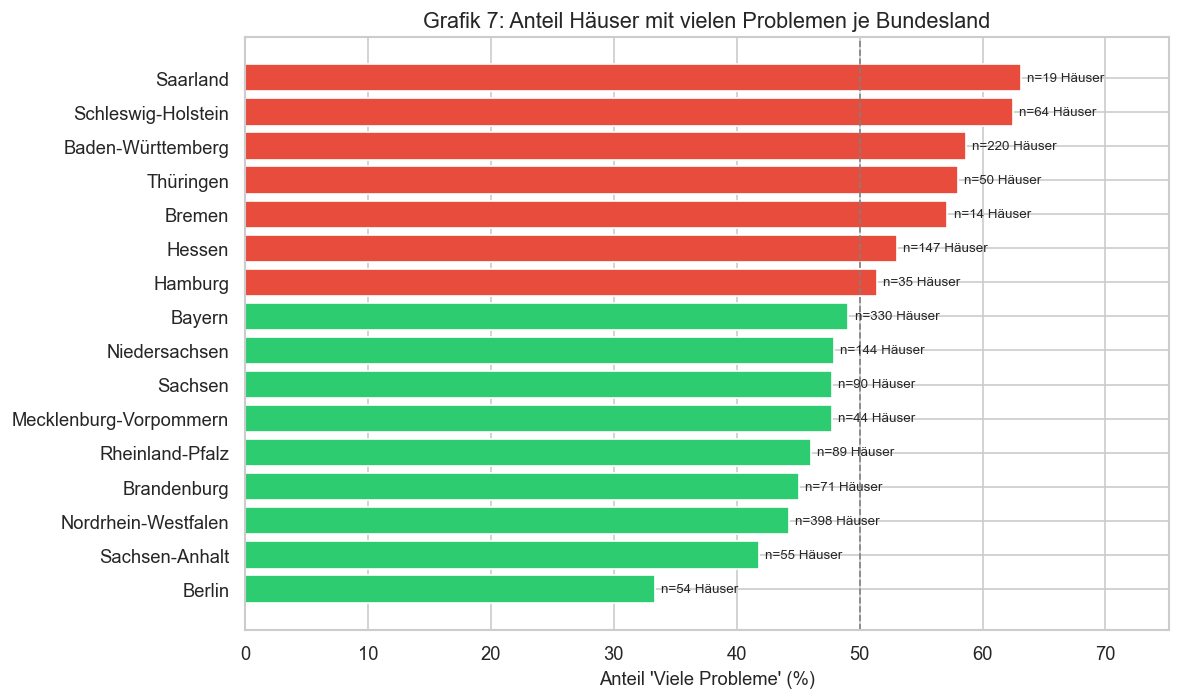


📌 Befund: Höchster Anteil: Saarland (63.2%), niedrigster: Berlin (33.3%). Regionale Unterschiede sichtbar? Achtung: kleine n beachten.


In [7]:
# ── Grafik 7: Bundesland — Anteil 'Viele Probleme' ───────────────
bl_pct = (
    df.groupby("SO.Bundesland")["hat_viele_Probleme"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "quote", "count": "n"})
    .sort_values("quote", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if q > 0.5 else "#2ecc71" for q in bl_pct["quote"]]
ax.barh(bl_pct.index, bl_pct["quote"] * 100, color=colors, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 7: Anteil Häuser mit vielen Problemen je Bundesland")
ax.set_xlim(0, bl_pct["quote"].max() * 100 + 12)   # Platz rechts für die n=...-Beschriftung
for i, (idx, row) in enumerate(bl_pct.iterrows()):
    ax.text(row["quote"]*100 + 0.5, i, f"n={row['n']:.0f} Häuser", va="center", fontsize=8)
plt.tight_layout()
plt.show()

top = bl_pct.iloc[-1]
low = bl_pct.iloc[0]
print(f"\n📌 Befund: Höchster Anteil: {top.name} ({top['quote']:.1%}), "
      f"niedrigster: {low.name} ({low['quote']:.1%}). "
      f"Regionale Unterschiede sichtbar? Achtung: kleine n beachten.")

---
## 4️⃣ Korrelationen & Zusammenhänge

### 📊 Grafik 8 — Korrelationsmatrix
Heatmap aller Korrelationen (Pearson r) zwischen den numerischen Merkmalen. Zeigt auf einen Blick, welche Merkmale miteinander und mit der Ziel-Variable (`hat_viele_Probleme`) zusammenhängen. Stärkste Zusammenhänge werden anschließend einzeln ausgegeben.

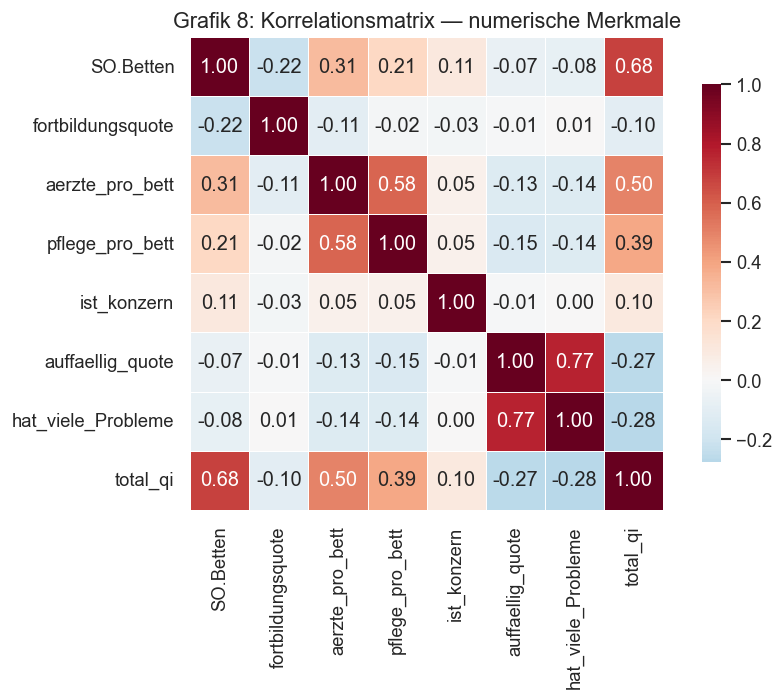


Korrelation mit hat_viele_Probleme (|r|):
  auffaellig_quote         : +0.766
  total_qi                 : -0.279
  aerzte_pro_bett          : -0.139
  pflege_pro_bett          : -0.136
  SO.Betten                : -0.080
  fortbildungsquote        : +0.008
  ist_konzern              : +0.004

📌 Befund: Welches Merkmal korreliert am stärksten mit der Ziel-Variable?


In [8]:
# ── Grafik 8: Korrelations-Heatmap ──────────────────────────────
num_cols = ["SO.Betten", "fortbildungsquote", "aerzte_pro_bett", "pflege_pro_bett",
            "ist_konzern", "auffaellig_quote", "hat_viele_Probleme", "total_qi"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Grafik 8: Korrelationsmatrix — numerische Merkmale")
plt.tight_layout()
plt.show()

# Stärkste Korrelation mit Ziel-Variable
target_corr = corr["hat_viele_Probleme"].drop("hat_viele_Probleme").abs().sort_values(ascending=False)
print("\nKorrelation mit hat_viele_Probleme (|r|):")
for col, val in target_corr.items():
    print(f"  {col:25s}: {corr.loc[col,'hat_viele_Probleme']:+.3f}")
print("\n📌 Befund: Welches Merkmal korreliert am stärksten mit der Ziel-Variable?")

### 📊 Grafik 9 — Streudiagramm: Bettenzahl vs. Ärzte pro Bett
Scatterplot mit farblicher Unterscheidung der zwei Gruppen. Prüft visuell, ob große Häuser mehr Ärzte pro Bett haben (möglicher Störfaktor) — und ob sich die Gruppen räumlich trennen lassen. Bettenzahl und Ärztedichte werden gekappt, um extreme Ausreißer aus dem sichtbaren Bereich zu halten.

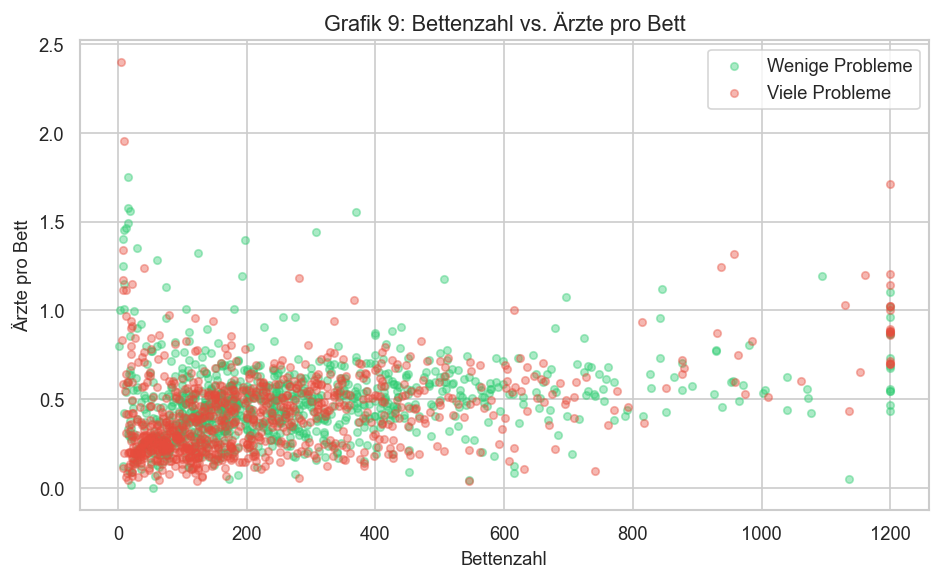


📌 Störfaktor-Check: Große Häuser haben tendenziell mehr Ärzte in absoluten Zahlen, aber aerzte_pro_bett normiert das bereits — Zusammenhang prüfen.


In [9]:
# ── Grafik 9: Scatter — Betten vs. Ärzte pro Bett ────────────────
# Störfaktor: Große Häuser haben mehr Personal — zeigt das auch aerzte_pro_bett?
fig, ax = plt.subplots(figsize=(8, 5))
for g in [0, 1]:
    sub = df[df["hat_viele_Probleme"]==g]
    ax.scatter(sub["SO.Betten"].clip(upper=1200),
               sub["aerzte_pro_bett"].clip(upper=3),
               c=FARBEN[g], label=LABELS[g], alpha=0.4, s=20)
ax.set_xlabel("Bettenzahl")
ax.set_ylabel("Ärzte pro Bett")
ax.set_title("Grafik 9: Bettenzahl vs. Ärzte pro Bett")
ax.legend()
plt.tight_layout()
plt.show()

print("\n📌 Störfaktor-Check: Große Häuser haben tendenziell mehr Ärzte in absoluten Zahlen, "
      "aber aerzte_pro_bett normiert das bereits — Zusammenhang prüfen.")

### 📊 Grafik 10 — Störfaktor: Bettengröße je Trägerschaft
Boxplot der Bettenzahl getrennt nach Trägerart. Prüft den Störfaktor hinter dem Trägerschaftsbefund: Wenn private Häuser systematisch kleiner sind, könnte der Trägereffekt (Grafik 3) in Wirklichkeit ein Größeneffekt sein.

C:\Users\Admin\AppData\Local\Temp\ipykernel_11532\3627754092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="KH.Träger.Art", y="SO.Betten",


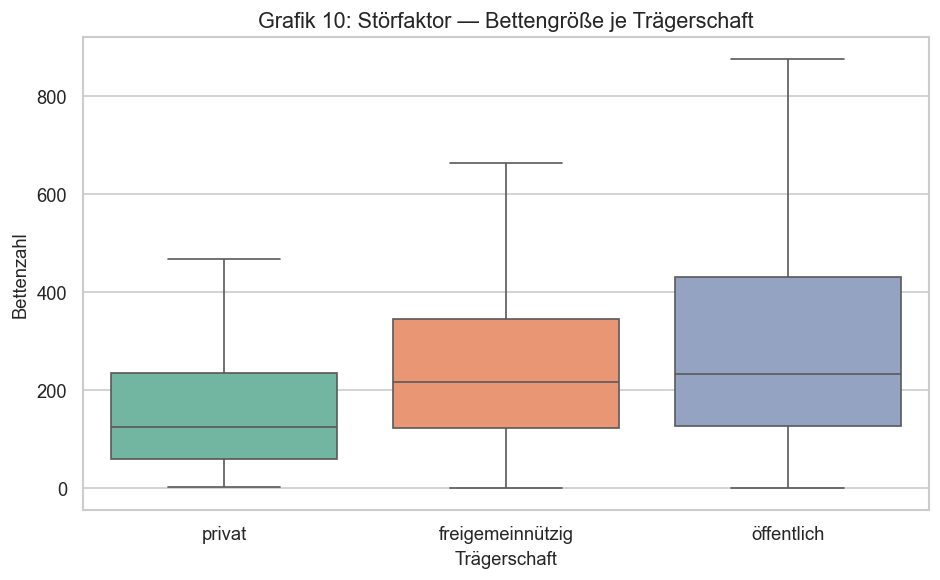

  privat              : Median 125 Betten
  freigemeinnützig    : Median 217 Betten
  öffentlich          : Median 233 Betten

📌 Störfaktor-Check: Wenn Träger mit Qualitätsproblemen auch größer/kleiner sind, muss der Trägereffekt mit Vorsicht interpretiert werden.


In [10]:
# ── Grafik 10: Störfaktor Träger × Bettengröße ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_clean = df.dropna(subset=["KH.Träger.Art"])
order = df_clean.groupby("KH.Träger.Art")["SO.Betten"].median().sort_values().index
sns.boxplot(data=df_clean, x="KH.Träger.Art", y="SO.Betten",
            order=order, palette="Set2",
            showfliers=False, ax=ax)
ax.set_xlabel("Trägerschaft")
ax.set_ylabel("Bettenzahl")
ax.set_title("Grafik 10: Störfaktor — Bettengröße je Trägerschaft")
plt.tight_layout()
plt.show()

for t in order:
    m = df_clean[df_clean["KH.Träger.Art"]==t]["SO.Betten"].median()
    print(f"  {t:20s}: Median {m:.0f} Betten")
print("\n📌 Störfaktor-Check: Wenn Träger mit Qualitätsproblemen auch größer/kleiner sind, "
      "muss der Trägereffekt mit Vorsicht interpretiert werden.")

### 📊 Grafik 11 — Pflegekräfte pro Bett
Boxplot: Pflegekräfte pro Bett getrennt nach Gruppe (wenige/viele Probleme). Ergänzt Grafik 5+6 um das Pflegepersonal als zweiten Personalindikator — prüft, ob das gleiche Muster wie bei Ärzte/Bett zu sehen ist.

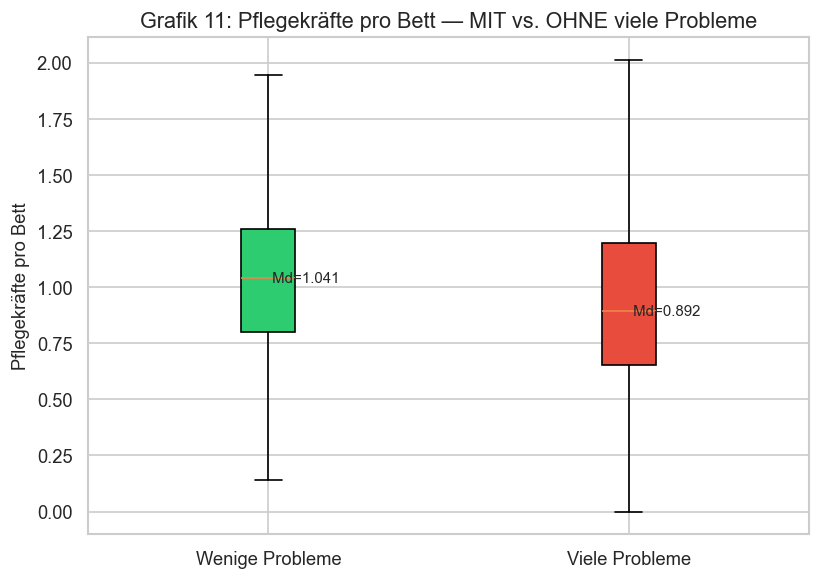

  Pflegekräfte/Bett   : Wenige=1.041, Viele=0.892

📌 Befund: Ähnlich wie aerzte_pro_bett — weniger Pflegepersonal/Bett bei Häusern mit vielen Problemen.


In [11]:
# ── Grafik 11: Pflegekräfte pro Bett — Boxplot ──────────────────
fig, ax = plt.subplots(figsize=(7, 5))
data = [df[df["hat_viele_Probleme"]==g]["pflege_pro_bett"].dropna() for g in [0, 1]]
bp = ax.boxplot(data, tick_labels=["Wenige Probleme", "Viele Probleme"],
                patch_artist=True, showfliers=False)
bp["boxes"][0].set_facecolor(FARBEN[0])
bp["boxes"][1].set_facecolor(FARBEN[1])
ax.set_ylabel("Pflegekräfte pro Bett")
ax.set_title("Grafik 11: Pflegekräfte pro Bett — MIT vs. OHNE viele Probleme")
for g in [0, 1]:
    m = df[df["hat_viele_Probleme"]==g]["pflege_pro_bett"].median()
    ax.text(g+1, m, f" Md={m:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

m0 = df[df["hat_viele_Probleme"]==0]["pflege_pro_bett"].median()
m1 = df[df["hat_viele_Probleme"]==1]["pflege_pro_bett"].median()
print(f"  Pflegekräfte/Bett   : Wenige={m0:.3f}, Viele={m1:.3f}")
print("\n📌 Befund: Ähnlich wie aerzte_pro_bett — weniger Pflegepersonal/Bett bei Häusern mit vielen Problemen.")

### 📊 Grafik 12 — Konzernzugehörigkeit
Balkendiagramm: Anteil „Viele Probleme" für Konzernhäuser vs. unabhängige Häuser. Prüft, ob die Einbettung in einen Konzernverbund mit dem Qualitätsniveau zusammenhängt.

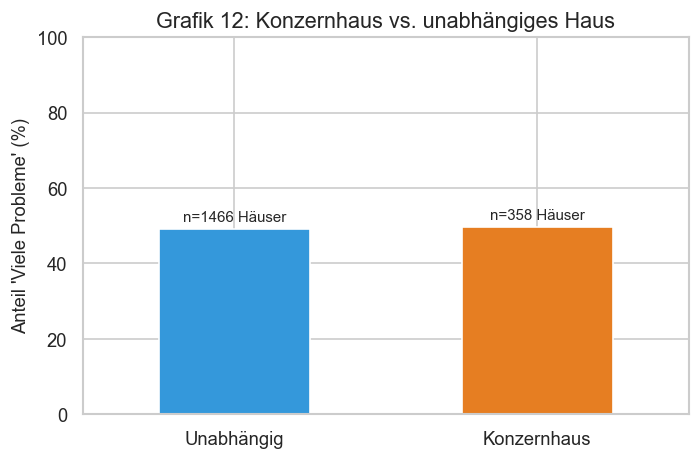

  Konzernhaus  : 49.7% viele Probleme (n=358)
  Unabhängig   : 49.2% viele Probleme (n=1466)

📌 Befund: Praktisch kein Unterschied — Konzernzugehörigkeit erklärt die Auffälligkeitsquote nicht (siehe Chi²-Test unten).


In [12]:
# ── Grafik 12: Konzernzugehörigkeit — Anteil 'Viele Probleme' ────
konzern_pct = (df.groupby("ist_konzern")["hat_viele_Probleme"].mean() * 100).rename(
    {0: "Unabhängig", 1: "Konzernhaus"}
)
n_vals = df.groupby("ist_konzern").size().rename({0: "Unabhängig", 1: "Konzernhaus"})
fig, ax = plt.subplots(figsize=(6, 4))
konzern_pct.plot(kind="bar", ax=ax, color=["#3498db", "#e67e22"], edgecolor="white")
ax.set_xlabel("")
ax.set_ylabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 12: Konzernhaus vs. unabhängiges Haus")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 100)
for i, (idx, val) in enumerate(konzern_pct.items()):
    ax.text(i, val + 2, f"n={n_vals[idx]} Häuser", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"  Konzernhaus  : {konzern_pct['Konzernhaus']:.1f}% viele Probleme (n={n_vals['Konzernhaus']})")
print(f"  Unabhängig   : {konzern_pct['Unabhängig']:.1f}% viele Probleme (n={n_vals['Unabhängig']})")
print("\n📌 Befund: Praktisch kein Unterschied — Konzernzugehörigkeit erklärt die Auffälligkeitsquote nicht (siehe Chi²-Test unten).")

---
## 5️⃣ Zusammenfassung der Befunde

### 📋 Zusammenfassung der deskriptiven Befunde

**Datensatz:** 1.824 Krankenhäuser, Ziel-Variable annähernd ausgeglichen (925 wenige Probleme vs. 899 viele Probleme ≈ 50/50).

---

#### 1. Auffällig-Quote (Grafik 1)
- Der Median der auffällig-Quote liegt bei **77 %** — die meisten Krankenhäuser weisen einen hohen Anteil auffälliger Qualitätsindikatoren auf.
- Die Verteilung ist **linkssteil**: Sehr wenige Häuser haben eine niedrige Auffällig-Quote.

#### 2. Bettenzahl (Grafik 2)
- Häuser mit **wenigen Problemen** haben im Median **214 Betten**, Häuser mit **vielen Problemen** nur **170 Betten**.
- → Größere Krankenhäuser tendieren eher zu **weniger** Qualitätsproblemen.

#### 3. Trägerschaft (Grafik 3)
- **Private** Träger: **56,5 %** haben viele Probleme.
- **Freigemeinnützige** Träger: **46,4 %** haben viele Probleme.
- **Öffentliche** Träger: **46,7 %** haben viele Probleme.
- → Private Krankenhäuser weisen den höchsten Anteil an Qualitätsproblemen auf.

#### 4. Uni-Kliniken vs. normale Häuser (Grafik 4)
- Uni-Kliniken: **47,3 %** viele Probleme | Normale Häuser: **49,4 %** viele Probleme.
- → **Kein nennenswerter Unterschied** zwischen Uni- und Nicht-Uni-Kliniken.

#### 5. Fortbildungsquote & Ärzte pro Bett (Grafik 5+6)
- **Fortbildungsquote:** Median bei beiden Gruppen identisch (**0,667**) → kein Unterschied.
- **Ärzte pro Bett:** Wenige Probleme = **0,468**, Viele Probleme = **0,390**.
- → Häuser mit **mehr Ärzten pro Bett** haben tendenziell **weniger** Qualitätsprobleme.

#### 6. Bundesländer (Grafik 7)
- Höchster Anteil: **Saarland** mit **63,2 %** (n=19, kleine Stichprobe!).
- Niedrigster Anteil: **Berlin** mit **33,3 %** (n=54).
- → Es gibt **regionale Unterschiede**, jedoch sind kleine Bundesländer (wie Saarland) mit Vorsicht zu interpretieren.

#### 7. Korrelationen (Grafik 8)
- **Stärkster Zusammenhang** mit der Ziel-Variable: `auffaellig_quote` (r = **+0,77**) — erwartungsgemäß, da die Ziel-Variable daraus abgeleitet wurde.
- `total_qi`: r = **−0,28** (moderat negativ).
- `aerzte_pro_bett`: r = **−0,14** (schwacher negativer Zusammenhang).
- `SO.Betten`: r = **−0,08** (sehr schwach).
- `fortbildungsquote`: r ≈ **0,01** (kein Zusammenhang).

#### 8. Störfaktoren (Grafik 9+10)
- Die Bettengröße variiert zwischen Trägerarten — der **Trägereffekt** könnte teilweise durch die **Hausgröße** konfundiert sein.
- `aerzte_pro_bett` ist bereits normiert, zeigt aber dennoch einen leichten Zusammenhang mit der Bettenzahl.

---

### 🔑 Kernbefunde

| Befund | Richtung | Stärke |
|--------|----------|--------|
| Auffällig-Quote → viele Probleme | positiv | sehr stark (r=0,77) |
| Ärzte pro Bett → viele Probleme | negativ | schwach (r=−0,14) |
| Private Trägerschaft → viele Probleme | positiv | moderat (56,5 % vs. 46 %) |
| Hausgröße (Betten) → viele Probleme | negativ | sehr schwach (r=−0,08) |
| Fortbildungsquote → viele Probleme | — | kein Zusammenhang |
| Uni-Status → viele Probleme | — | kein Zusammenhang |

> **Fazit:** Die auffällig-Quote dominiert als erklärender Faktor. Darüber hinaus zeigen **Ärztedichte** und **private Trägerschaft** die deutlichsten Zusammenhänge mit Qualitätsproblemen. Fortbildungsquote und Uni-Status spielen offenbar keine Rolle. Regionale Effekte existieren, erfordern aber aufgrund kleiner Stichproben weitere Prüfung.

---
## 6️⃣ Inferenzstatistik — T-Test, ANOVA & Konfidenzintervalle

### 🧮 T-Tests, Chi²-Test, ANOVA & Konfidenzintervalle
Statistische Absicherung der in den Grafiken sichtbaren Unterschiede: T-Test für Ärzte/Bett und Pflegekräfte/Bett (zwei Gruppen, metrisch), Chi²-Test für Konzernzugehörigkeit (zwei kategoriale Gruppen), ANOVA für Trägerschaft (drei Gruppen), 95 %-Konfidenzintervalle für Ärzte/Bett. Ziel: Sind die beobachteten Unterschiede statistisch signifikant oder zufällig?

In [13]:
from scipy import stats

# ── T-Test: Ärzte/Bett MIT vs. OHNE viele Probleme ──────────────
g0 = df[df["hat_viele_Probleme"]==0]["aerzte_pro_bett"].dropna()
g1 = df[df["hat_viele_Probleme"]==1]["aerzte_pro_bett"].dropna()

t_stat, p_val = stats.ttest_ind(g0, g1)
print("── T-Test: Ärzte pro Bett (Wenige vs. Viele Probleme) ──")
print(f"  Wenige Probleme:  Ø = {g0.mean():.3f}  (n={len(g0)})")
print(f"  Viele Probleme:   Ø = {g1.mean():.3f}  (n={len(g1)})")
print(f"  t-Statistik = {t_stat:.3f}  |  p-Wert = {p_val:.4f}")
if p_val < 0.05:
    print("  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Unterschied (α=0.05)")

print()

# ── T-Test: Pflegekräfte/Bett MIT vs. OHNE viele Probleme ───────
gp0 = df[df["hat_viele_Probleme"]==0]["pflege_pro_bett"].dropna()
gp1 = df[df["hat_viele_Probleme"]==1]["pflege_pro_bett"].dropna()

t_stat_p, p_val_p = stats.ttest_ind(gp0, gp1)
print("── T-Test: Pflegekräfte pro Bett (Wenige vs. Viele Probleme) ──")
print(f"  Wenige Probleme:  Ø = {gp0.mean():.3f}  (n={len(gp0)})")
print(f"  Viele Probleme:   Ø = {gp1.mean():.3f}  (n={len(gp1)})")
print(f"  t-Statistik = {t_stat_p:.3f}  |  p-Wert = {p_val_p:.4f}")
if p_val_p < 0.05:
    print("  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Unterschied (α=0.05)")

print()

# ── Chi²-Test: ist_konzern vs. hat_viele_Probleme ────────────────
ct = pd.crosstab(df["ist_konzern"], df["hat_viele_Probleme"])
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(ct)
print("── Chi²-Test: Konzernzugehörigkeit vs. viele Probleme ──")
print(ct.to_string())
print(f"  Chi² = {chi2_stat:.3f}  |  p-Wert = {p_chi2:.4f}  |  dof = {dof}")
if p_chi2 < 0.05:
    print("  → Zusammenhang ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Zusammenhang (α=0.05) — Konzernzugehörigkeit ist kein Prädiktor")

print()

# ── ANOVA: auffaellig_quote nach Trägerschaft ────────────────────
traeger_gruppen = [
    df[df["KH.Träger.Art"]==t]["auffaellig_quote"].dropna()
    for t in ["privat", "freigemeinnützig", "öffentlich"]
]
f_stat, p_anova = stats.f_oneway(*traeger_gruppen)
print("── ANOVA: auffällig-Quote nach Trägerschaft ──")
for t, g in zip(["privat", "freigemeinnützig", "öffentlich"], traeger_gruppen):
    print(f"  {t:20s}: Ø = {g.mean():.3f}  (n={len(g)})")
print(f"  F-Statistik = {f_stat:.3f}  |  p-Wert = {p_anova:.4f}")
if p_anova < 0.05:
    print("  → Mindestens eine Gruppe unterscheidet sich SIGNIFIKANT")
else:
    print("  → Kein signifikanter Unterschied zwischen den Gruppen")

print()

# ── Konfidenzintervalle für Gruppen-Mittelwerte (95 %) ───────────
print("── 95%-Konfidenzintervalle: Ärzte pro Bett ──")
for label_ci, gruppe in [("Wenige Probleme", g0), ("Viele Probleme", g1)]:
    ci = stats.t.interval(0.95, df=len(gruppe)-1,
                          loc=gruppe.mean(), scale=stats.sem(gruppe))
    print(f"  {label_ci}: [{ci[0]:.3f}, {ci[1]:.3f}]  (Ø={gruppe.mean():.3f})")

print("\n📌 Befund: Sind die Unterschiede statistisch gesichert?")

── T-Test: Ärzte pro Bett (Wenige vs. Viele Probleme) ──
  Wenige Probleme:  Ø = 0.483  (n=923)
  Viele Probleme:   Ø = 0.418  (n=896)
  t-Statistik = 6.002  |  p-Wert = 0.0000
  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)

── T-Test: Pflegekräfte pro Bett (Wenige vs. Viele Probleme) ──
  Wenige Probleme:  Ø = 1.072  (n=924)
  Viele Probleme:   Ø = 0.951  (n=896)
  t-Statistik = 5.846  |  p-Wert = 0.0000
  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)

── Chi²-Test: Konzernzugehörigkeit vs. viele Probleme ──
hat_viele_Probleme    0    1
ist_konzern                 
0                   745  721
1                   180  178
  Chi² = 0.015  |  p-Wert = 0.9013  |  dof = 1
  → Kein signifikanter Zusammenhang (α=0.05) — Konzernzugehörigkeit ist kein Prädiktor

── ANOVA: auffällig-Quote nach Trägerschaft ──
  privat              : Ø = 0.793  (n=503)
  freigemeinnützig    : Ø = 0.745  (n=608)
  öffentlich          : Ø = 0.752  (n=685)
  F-Statistik = 11.323  |  p-Wert = 0.0000
  → 

### 🔢 Pivot-Tabelle: Trägerschaft × Uni-Status
Kreuztabelle der mittleren `auffaellig_quote` nach Trägerart (Zeilen) und Uni-Status (Spalten) + Gesamt-Spalte. Zeigt, ob der Trägerschaftseffekt bei Uni-Kliniken anders aussieht als bei normalen Häusern (Interaktionseffekt).

In [13]:
# ── pivot_table: Träger × Uni-Status ────────────────────────────
pivot = df.pivot_table(
    values="auffaellig_quote",
    index="KH.Träger.Art",
    columns="SO.Uni",
    aggfunc="mean"
).rename(columns={0: "Nicht-Uni", 1: "Uni-Klinik"})

pivot["Gesamt"] = df.groupby("KH.Träger.Art")["auffaellig_quote"].mean()
pivot = pivot.round(3)

print("── pivot_table: Ø auffällig-Quote nach Träger × Uni-Status ──")
print(pivot.to_string())
print("\n📌 Befund: Unterscheiden sich Uni-Kliniken je nach Träger?")

── pivot_table: Ø auffällig-Quote nach Träger × Uni-Status ──
SO.Uni            Nicht-Uni  Uni-Klinik  Gesamt
KH.Träger.Art                                  
freigemeinnützig      0.745       0.713   0.745
privat                0.793       0.791   0.793
öffentlich            0.755       0.723   0.752

📌 Befund: Unterscheiden sich Uni-Kliniken je nach Träger?


### 💾 Alle 12 Grafiken als PNG speichern
Erzeugt alle Grafiken (G1–G12) erneut in einer schlanken Version ohne interaktive Legende und speichert sie als PNG-Dateien in `grafiken/`. Diese Dateien werden vom Dashboard, der Word-Dokumentation und der Präsentation genutzt.

In [ ]:
import subprocess, sys
from pathlib import Path

skript = Path("../scripts/Grafiken_Speichern.py").resolve()
result = subprocess.run([sys.executable, str(skript)], capture_output=True, text=True,
                        cwd=str(skript.parent.parent))
print(result.stdout)
if result.returncode != 0:
    print("FEHLER:", result.stderr)

### 📋 Alle Kernergebnisse ausgeben
Gibt eine kompakte Übersicht aller wichtigen Befunde als Text aus: Median, Gruppenvergleiche für jedes Merkmal, stärkstes Korrelationsmerkmal. Dient als schnelle Zusammenfassung ohne erneutes Durchlesen aller Grafiken.

In [14]:
print("=" * 60)
print("BEFUNDE — Deskriptive Analyse")
print("=" * 60)

print(f"""
Grafik 1 — auffällig-Quote:
  Median {df['auffaellig_quote'].median():.0%}, linkssteil verteilt.

Grafik 2 — Bettenzahl:
  Median: Wenige Probleme = {df[df['hat_viele_Probleme']==0]['SO.Betten'].median():.0f} Betten,
          Viele Probleme   = {df[df['hat_viele_Probleme']==1]['SO.Betten'].median():.0f} Betten.

Grafik 3 — Trägerschaft:
  privat          = {df[df['KH.Träger.Art']=='privat']['hat_viele_Probleme'].mean():.1%} haben viele Probleme
  freigemeinnützig= {df[df['KH.Träger.Art']=='freigemeinnützig']['hat_viele_Probleme'].mean():.1%}
  öffentlich      = {df[df['KH.Träger.Art']=='öffentlich']['hat_viele_Probleme'].mean():.1%}

Grafik 4 — Uni-Kliniken:
  Uni-Kliniken:   {df[df['SO.Uni']==1]['hat_viele_Probleme'].mean():.1%}
  Normale Häuser: {df[df['SO.Uni']==0]['hat_viele_Probleme'].mean():.1%}

Grafik 5+6 — Fortbildungsquote & Ärzte/Bett:
  Fortbildung: Wenige={df[df['hat_viele_Probleme']==0]['fortbildungsquote'].median():.3f}, Viele={df[df['hat_viele_Probleme']==1]['fortbildungsquote'].median():.3f}
  Ärzte/Bett:  Wenige={df[df['hat_viele_Probleme']==0]['aerzte_pro_bett'].median():.3f}, Viele={df[df['hat_viele_Probleme']==1]['aerzte_pro_bett'].median():.3f}

Grafik 8 — Stärkste Korrelation mit Ziel-Variable:
  → {df[['SO.Betten','fortbildungsquote','aerzte_pro_bett','total_qi']].corrwith(df['hat_viele_Probleme']).abs().idxmax()}
""")
print("⚠️  Hinweis: Kein Zusammenhang ist ein valides Ergebnis.")

BEFUNDE — Deskriptive Analyse

Grafik 1 — auffällig-Quote:
  Median 77%, linkssteil verteilt.

Grafik 2 — Bettenzahl:
  Median: Wenige Probleme = 214 Betten,
          Viele Probleme   = 170 Betten.

Grafik 3 — Trägerschaft:
  privat          = 56.5% haben viele Probleme
  freigemeinnützig= 46.4%
  öffentlich      = 46.7%

Grafik 4 — Uni-Kliniken:
  Uni-Kliniken:   47.3%
  Normale Häuser: 49.4%

Grafik 5+6 — Fortbildungsquote & Ärzte/Bett:
  Fortbildung: Wenige=0.667, Viele=0.667
  Ärzte/Bett:  Wenige=0.468, Viele=0.390

Grafik 8 — Stärkste Korrelation mit Ziel-Variable:
  → total_qi

⚠️  Hinweis: Kein Zusammenhang ist ein valides Ergebnis.
